In [24]:

import sys
import os
import time
import numpy as np

import MDAnalysis as mda
# from MDAnalysis.analysis import align
# from MDAnalysis.analysis import distances

import westpa
from westpa.analysis import Run

import matplotlib.pyplot as plt

In [25]:
def tmd_query():
    segment_resis = [[77, 149], [192, 245], [298, 362], [988, 1034], [857, 889], [900, 942], [1094, 1154]]
    #print("color blue, " + " or ".join([f"resi {sr[0]}-{sr[1]}" for sr in segment_resis]))

    segment_resis_all = [i for sr in segment_resis for i in range(sr[0], sr[1]+1)]
    query = " or ".join([f"resid {sr}" for sr in segment_resis_all])

    #indices = frame.top.select(f"protein and ({query})")

    # print_indices = frame.top.select(f"protein and name CA and ({query})")
    # print("+".join([str(i+1) for i in print_indices]))
    return f"protein and ({query})"


def ref_prot_crd():
    ref_frame_path = '/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/input.gro'
    ref_frame = mda.Universe(ref_frame_path)
    ref_sel = ref_frame.select_atoms(f"{tmd_query()} and name CA")#not name H*")
    lig_sel = ref_frame.select_atoms("resname LJP and not name H*")
    return ref_sel.positions, lig_sel.positions

prot_pos, lig_pos = ref_prot_crd()

In [26]:
#this barely needs to be a method but having the .h5 stuff compartmentalized is nice
def load_h5_pcs(h5path, miniter, maxiter):
    
    run = Run.open(h5path)

    #set maximum iteration automatically
    if maxiter == -1:
        maxiter = run.num_iterations

    pcs = [iteration.pcoords for iteration in run if (iteration.number >= miniter and iteration.number < maxiter)]

    return pcs

In [27]:
#specify input file

cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [[f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1", "blue"],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2", "cyan"],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5", f"{cftr_refpc}/lip_glpg_1", "undecanol-1", "red"],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5", f"{cftr_refpc}/lip_glpg_2", "undecanol-2", "orange"]]

#westpa rounds to load
minround = 0
maxround = -1

run_ind = 0
ref_paths = ["/media/X01Raid01/Data_Backup/home/jborowsky/cftr-analysis/revisions/abbv-974-top/eq19.gro"]
ref_path = ref_paths[run_ind]
water_coords_data_paths = ["/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1"]
water_coords_data_path = water_coords_data_paths[run_ind]


In [28]:
pcs_all = load_h5_pcs(h5paths_names[run_ind][0], minround, maxround)

In [29]:
nbins = 51
binbounds = np.arange(0,nbins,1)
waters_by_bin = [[] for a in range(nbins)]

#loop over WE rounds
for r in range(1,1000,10):
    
    #get progress coordinates of the walkers, accounting for the occasional corrupted file
    walkers = np.load(f"{water_coords_data_path}/pc_data_round_{r}_obs_0_v1.npy")
    pcs_flat = pcs_all[r-1][:,-1].flatten()
    pcs = [pcs_flat[w] for w in walkers]

    bins = np.digitize(pcs, binbounds)

    #load water coordinates
    waters = np.load(f"{water_coords_data_path}/pc_data_round_{r}_obs_1_v1.npy")
    print(waters.shape)
    #get coordinates of waters in each bin
    for b, w in zip(bins, waters):
        waters_by_bin[b].append(w)

waters_by_bin = [np.concatenate(w) if len(w) > 0 else np.array([]) for w in waters_by_bin]

for i, w in enumerate(waters_by_bin):
    print(f"{i}: {w.shape[0]}")

(4, 1326, 3)
(24, 1392, 3)
(28, 1349, 3)
(32, 1389, 3)
(40, 1445, 3)
(28, 1387, 3)
(28, 1364, 3)
(28, 1377, 3)
(32, 1427, 3)
(20, 1416, 3)
(24, 1370, 3)
(36, 1397, 3)
(56, 1379, 3)
(64, 1364, 3)
(64, 1448, 3)
(68, 1414, 3)
(80, 1394, 3)
(80, 1383, 3)
(80, 1398, 3)
(72, 1410, 3)
(80, 1374, 3)
(84, 1380, 3)
(84, 1367, 3)
(68, 1398, 3)
(84, 1378, 3)
(80, 1421, 3)
(80, 1430, 3)
(92, 1368, 3)
(92, 1384, 3)
(112, 1374, 3)
(108, 1401, 3)
(112, 1393, 3)
(100, 1416, 3)
(104, 1419, 3)
(108, 1408, 3)
(100, 1450, 3)
(100, 1410, 3)
(108, 1403, 3)
(108, 1394, 3)
(108, 1414, 3)
(104, 1391, 3)
(108, 1378, 3)
(100, 1381, 3)
(100, 1400, 3)
(100, 1386, 3)
(100, 1388, 3)
(100, 1463, 3)
(104, 1377, 3)
(100, 1419, 3)
(112, 1393, 3)
(108, 1394, 3)
(108, 1417, 3)
(104, 1395, 3)
(104, 1389, 3)
(112, 1413, 3)
(108, 1445, 3)
(112, 1423, 3)
(108, 1375, 3)
(108, 1350, 3)
(108, 1374, 3)
(112, 1400, 3)
(104, 1442, 3)
(108, 1371, 3)
(112, 1444, 3)
(108, 1380, 3)
(104, 1393, 3)
(100, 1396, 3)
(108, 1413, 3)
(108, 1397

(461233, 3)


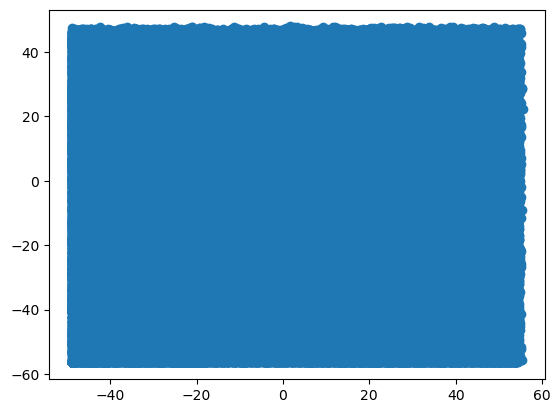

In [32]:
bin = 10
water_crd = waters_by_bin[bin]-np.mean(prot_pos, axis = 0)

print(water_crd.shape)
plt.scatter(water_crd[:,0],water_crd[:,1])

hist3d = np.histogramdd(water_crd, bins = [15,15,15], range=[[-30,30],[-30,30],[-20,20]], density=None, weights=None)

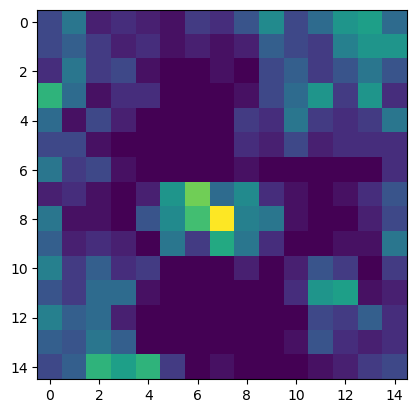

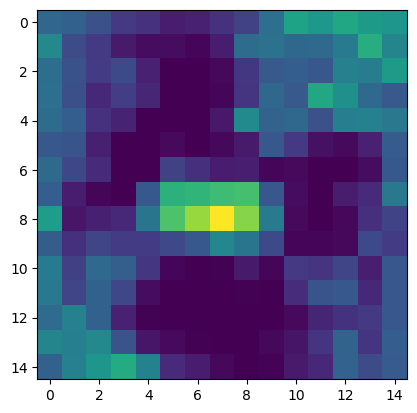

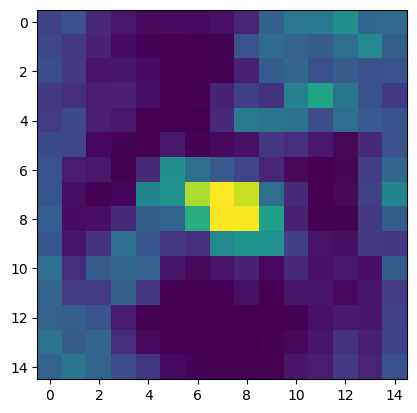

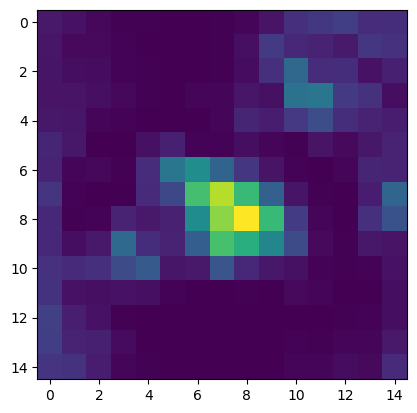

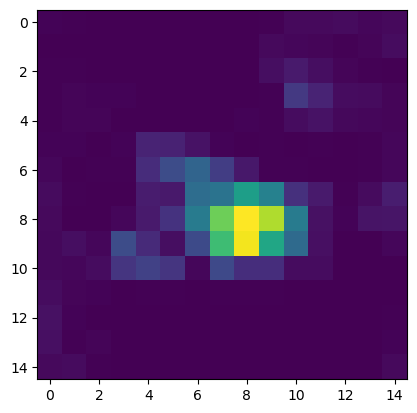

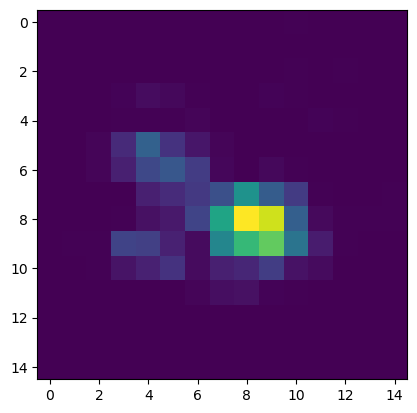

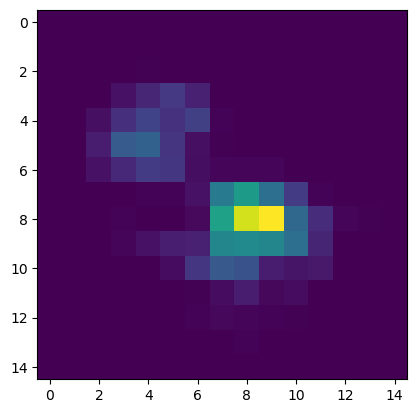

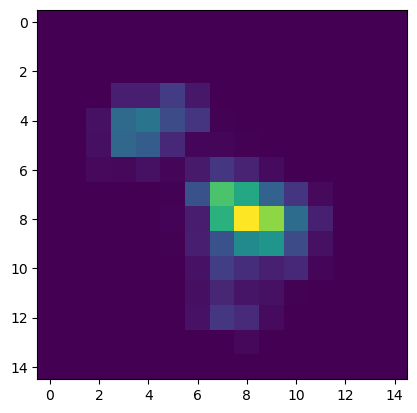

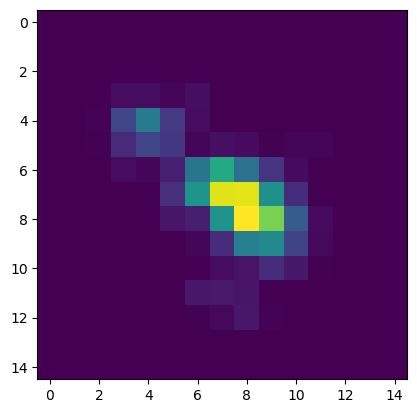

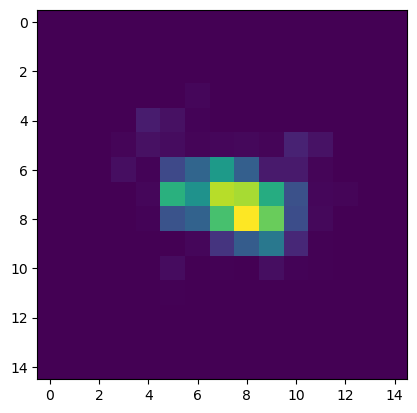

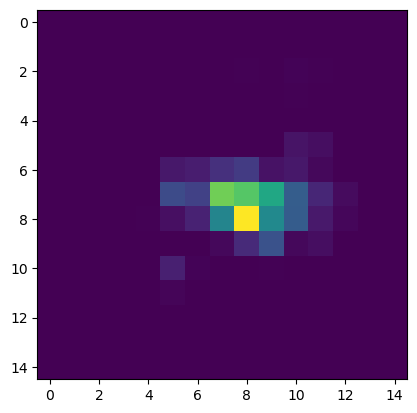

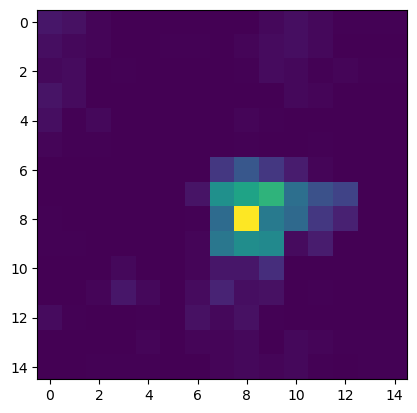

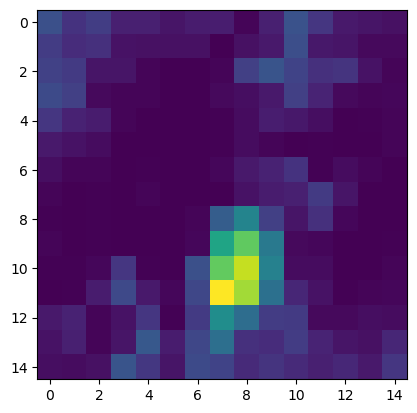

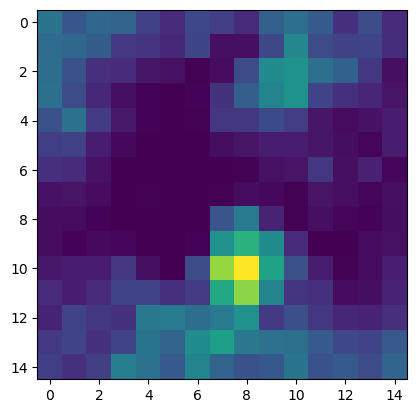

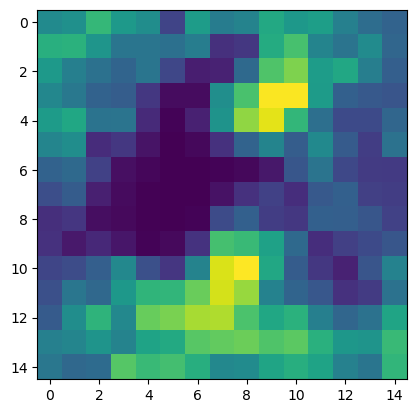

In [33]:
for i in range(15):
    plt.imshow(hist3d[0][:,:,i])
    plt.show()

In [14]:
np.sum(hist3d[0])

152190.0

In [ ]:

def coords_to_pml(coords, output_file="pseudoatoms.pml", object_name="points"):
    """
    Generate a PyMOL .pml script that creates pseudoatoms at given coordinates.

    Parameters
    ----------
    coords : (N,3) numpy array
        Array of xyz coordinates
    output_file : str
        Output .pml filename
    object_name : str
        Name of the PyMOL object
    """

    if coords.ndim != 2 or coords.shape[1] != 3:
        raise ValueError("coords must be an Nx3 numpy array")

    with open(output_file, "w") as f:
        f.write(f"delete {object_name}\n")

        for i, (x, y, z) in enumerate(coords, start=1):
            f.write(
                f"pseudoatom {object_name}, pos=[{x:.3f},{y:.3f},{z:.3f}], "
                f"name=P{i}, resi={i}, chain=A\n"
            )

        f.write(f"show spheres, {object_name}\n")
        f.write(f"set sphere_scale, 0.3, {object_name}\n")

bin = 1

coords_to_pml(waters_by_bin[bin], f"/home/jonathan/Documents/grabelab/cftr/independent-partial-dissociation/nonlip_glpg_1/topology/bin_{bin}_waters.pml")

# if __name__ == "__main__":

#     if len(sys.argv) < 3:
#         print("Usage: python coords_to_pml.py coords.npy output.pml")
#         sys.exit(1)

#     coords = np.load(sys.argv[1])
#     output_file = sys.argv[2]

#     coords_to_pml(coords, output_file)

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Example large dataset
# N = 200000
# coords = np.random.randn(N,3)
# x = coords[:,0]
# y = coords[:,1]
# z = coords[:,2]

mean_prot = np.mean(prot_pos, axis = 0)

bin = 5
interval=1

#print(waters_by_bin[bin])

x = waters_by_bin[bin][::interval,0]-mean_prot[0]
y = waters_by_bin[bin][::interval,1]-mean_prot[1]
z = waters_by_bin[bin][::interval,2]-mean_prot[2]
print(x.shape)
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="markers",
        hoverinfo="skip",
        marker=dict(
            size=3,
            opacity=0.7,
            color="red"#z,          # GPU color mapping
            #colorscale="Viridis"
        )
    )
)


if True:
    xp = prot_pos[:,0]-mean_prot[0]
    yp = prot_pos[:,1]-mean_prot[1]
    zp = prot_pos[:,2]-mean_prot[2]

    fig.add_trace(
        go.Scatter3d(
            x=xp,
            y=yp,
            z=zp,
            mode="markers",
            hoverinfo="skip",
            marker=dict(
                size=4,
                opacity=1,
                color="black"
            )
        )
    )

    xl = lig_pos[:,0]-mean_prot[0]
    yl = lig_pos[:,1]-mean_prot[1]
    zl = lig_pos[:,2]-mean_prot[2]

    fig.add_trace(
        go.Scatter3d(
            x=xl,
            y=yl,
            z=zl,
            mode="markers",
            hoverinfo="skip",
            marker=dict(
                size=4,
                opacity=1,
                color="blue"
            )
        )
    )

fig.update_layout(
    title="Large Interactive 3D Scatter",
    scene=dict(
        xaxis = dict(nticks=4, range=[-30,30],),
        yaxis = dict(nticks=4, range=[-30,30],),
        zaxis = dict(nticks=4, range=[-30,30],),
        aspectratio=dict(x=1, y=1, z=1),
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z"
    ),
    width=1000,
    height=1000,
    margin=dict(l=0,r=0,b=0,t=40),
    scene_camera=dict(
            eye=dict(x=3, y=3, z=3)
        )

)

fig.show(config={"scrollZoom": True})